# Deep Learning for Predictive Maintenance

## Project Overview

This notebook develops a feed-forward neural network (MLP) using PyTorch to predict machine failure from the AI4I 2020 Predictive Maintenance dataset.

The deep learning model is developed as an extension of the previous machine learning project, where Random Forest was used as the classical machine learning baseline.

### Objectives

- Build a neural network for binary machine-failure classification.
- Train the model using mini-batch gradient descent with SGD and momentum.
- Monitor training and validation performance across epochs.
- Analyze whether the model suffers from overfitting or underfitting.
- Evaluate the final model using appropriate classification metrics.
- Compare the neural network with the previous Random Forest baseline.


# 1. Import Library

In [1]:
# Phase 1 — Environment Setup
# Import libraries required for data processing, visualization,
# model development, training, and evaluation.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# 2. Data Loading & Initial Inspection

In [2]:
df = pd.read_csv("../data/ai4i2020.csv")

print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [4]:
leakage_features = [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

drop_features = [
    "UDI",
    "Product ID",
    *leakage_features
]


df = df.drop(columns=drop_features)  # remove unimportant columns
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


# 3. Define Features and Target

In [5]:
target = "Machine failure"
X = df.drop(columns=[target])  # features
y = df[target]

print(X.shape, y.shape)

(10000, 6) (10000,)


In [6]:
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


In [7]:
y.value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

# 4. Train / Validation / Test Split

In [8]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y, # This is important to maintain the same proportion of classes in the train and test sets
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,
    stratify=y_temp,
    random_state=42
)

In [9]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTrain:")
print(y_train.value_counts())

print("\nValidation:")
print(y_val.value_counts())

print("\nTest:")
print(y_test.value_counts())

Train: (6999, 6)
Validation: (1501, 6)
Test: (1500, 6)

Train:
Machine failure
0    6762
1     237
Name: count, dtype: int64

Validation:
Machine failure
0    1450
1      51
Name: count, dtype: int64

Test:
Machine failure
0    1449
1      51
Name: count, dtype: int64


# 5. Preprocessing & Feature Scaling

In [10]:
# Identify categorical and numerical features

categorical_features = ["Type"]

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['Type']
Numerical features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


In [11]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [12]:
# One-hot encode the categorical Type feature

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train[categorical_features])
X_val_cat = encoder.transform(X_val[categorical_features])
X_test_cat = encoder.transform(X_test[categorical_features])

print("Encoded categorical shape:")
print("Train:", X_train_cat.shape)
print("Validation:", X_val_cat.shape)
print("Test:", X_test_cat.shape)

Encoded categorical shape:
Train: (6999, 3)
Validation: (1501, 3)
Test: (1500, 3)


In [13]:
# Standardize numerical features using training data only

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numerical_features])
X_val_num = scaler.transform(X_val[numerical_features])
X_test_num = scaler.transform(X_test[numerical_features])

print("Numerical feature shapes:")
print("Train:", X_train_num.shape)
print("Validation:", X_val_num.shape)
print("Test:", X_test_num.shape)

Numerical feature shapes:
Train: (6999, 5)
Validation: (1501, 5)
Test: (1500, 5)


In [14]:
# Combine numerical and encoded categorical features

X_train_processed = np.hstack([
    X_train_num,
    X_train_cat
])

X_val_processed = np.hstack([
    X_val_num,
    X_val_cat
])

X_test_processed = np.hstack([
    X_test_num,
    X_test_cat
])

print("Processed feature shapes:")
print("Train:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)

Processed feature shapes:
Train: (6999, 8)
Validation: (1501, 8)
Test: (1500, 8)


In [15]:
X_train_processed

array([[ 0.79820104,  0.80302089, -0.07790207, ...,  0.        ,
         1.        ,  0.        ],
       [-1.60337192, -1.35065095, -1.26653166, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.24784057,  0.93762538,  0.9440972 , ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.65274929, -0.0719083 , -0.71109727, ...,  0.        ,
         0.        ,  1.        ],
       [-0.10238882, -0.00460605, -0.78885809, ...,  0.        ,
         0.        ,  1.        ],
       [ 2.14908582,  2.35097252, -0.41671705, ...,  0.        ,
         1.        ,  0.        ]], shape=(6999, 8))

In [16]:
# Convert target variables to NumPy arrays

y_train_np = y_train.to_numpy(dtype=np.float32)
y_val_np = y_val.to_numpy(dtype=np.float32)
y_test_np = y_test.to_numpy(dtype=np.float32)

print("Target shapes:")
print("Train:", y_train_np.shape)
print("Validation:", y_val_np.shape)
print("Test:", y_test_np.shape)

Target shapes:
Train: (6999,)
Validation: (1501,)
Test: (1500,)


# 6. TensorDataset + DataLoader

In [17]:
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).unsqueeze(1)
y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).unsqueeze(1)

In [18]:
print(X_train_tensor.shape, y_train_tensor.shape)

torch.Size([6999, 8]) torch.Size([6999, 1])


In [19]:
train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=32
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=32
)

# 7. Build the Neural Network

In [20]:
class MLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

In [32]:
model = MLP(input_size=X_train_tensor.shape[1])

print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [ ]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)

## Baseline optimizer

In [ ]:
epochs = 100

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        output = model(X_batch)
        loss = criterion(output, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            output = model(X_batch)
            loss = criterion(output, y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch  10 | Train Loss: 0.1341 | Val Loss: 0.1330
Epoch  20 | Train Loss: 0.1129 | Val Loss: 0.1090
Epoch  30 | Train Loss: 0.0990 | Val Loss: 0.1014
Epoch  40 | Train Loss: 0.0970 | Val Loss: 0.0994
Epoch  50 | Train Loss: 0.0933 | Val Loss: 0.0984
Epoch  60 | Train Loss: 0.0927 | Val Loss: 0.0977
Epoch  70 | Train Loss: 0.0900 | Val Loss: 0.0968
Epoch  80 | Train Loss: 0.0892 | Val Loss: 0.0954
Epoch  90 | Train Loss: 0.0877 | Val Loss: 0.0945
Epoch 100 | Train Loss: 0.0868 | Val Loss: 0.0932


In [ ]:
model.eval()

with torch.no_grad():
    train_prob = torch.sigmoid(model(X_train_tensor))
    val_prob = torch.sigmoid(model(X_val_tensor))

    train_pred = (train_prob >= 0.5).float()
    val_pred = (val_prob >= 0.5).float()

    accuracy_train = (train_pred == y_train_tensor).float().mean()
    accuracy_val = (val_pred == y_val_tensor).float().mean()

print(f"Training Accuracy: {accuracy_train:.4f}")
print(f"Validation Accuracy: {accuracy_val:.4f}")

Training Accuracy: 0.9741
Validation Accuracy: 0.9714


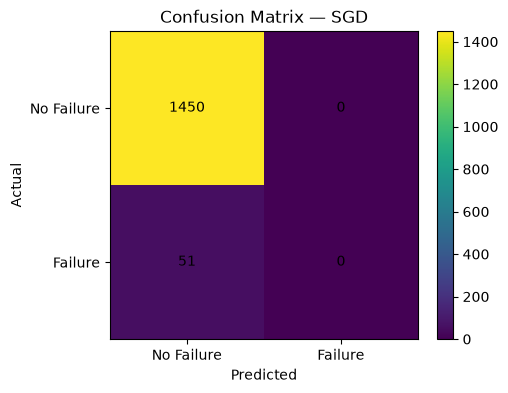

In [ ]:

cm = confusion_matrix(y_val_np, val_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.colorbar()

plt.xticks([0, 1], ["No Failure", "Failure"])
plt.yticks([0, 1], ["No Failure", "Failure"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — SGD")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [ ]:
# Print classification report
print("Classification Report:\n", classification_report(y_val_np, val_pred, target_names=['Loss', 'Win']))

Classification Report:
               precision    recall  f1-score   support

        Loss       0.97      1.00      0.98      1450
         Win       0.00      0.00      0.00        51

    accuracy                           0.97      1501
   macro avg       0.48      0.50      0.49      1501
weighted avg       0.93      0.97      0.95      1501



d:\proyek\predictive-maintenance-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\proyek\predictive-maintenance-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\proyek\predictive-maintenance-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

The model achieves high overall accuracy, but it fails to detect the minority Failure class, with 0.00 precision, recall, and F1-score. This indicates that accuracy alone is misleading for this imbalanced dataset.

## Implement Class-Weighted BCE

In [22]:
pos_weight = y_train_tensor.eq(0).sum() / y_train_tensor.eq(1).sum()

criterion_weighted = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

model_weighted = MLP(X_train_tensor.shape[1])

optimizer_weighted = torch.optim.SGD(
    model_weighted.parameters(),
    lr=0.01,
    momentum=0.9
)

In [23]:
for epoch in range(100):
    model_weighted.train()

    for X_batch, y_batch in train_loader:
        optimizer_weighted.zero_grad()

        output = model_weighted(X_batch)
        loss = criterion_weighted(output, y_batch)

        loss.backward()
        optimizer_weighted.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/100], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 0.4952
Epoch [20/100], Loss: 1.0617
Epoch [30/100], Loss: 0.2170
Epoch [40/100], Loss: 0.1215
Epoch [50/100], Loss: 0.1221
Epoch [60/100], Loss: 0.1977
Epoch [70/100], Loss: 0.5203
Epoch [80/100], Loss: 0.3340
Epoch [90/100], Loss: 0.2079
Epoch [100/100], Loss: 0.0762


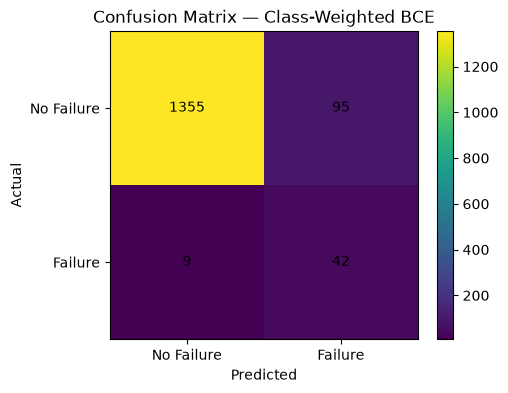

In [26]:
model_weighted.eval()

with torch.no_grad():
    weighted_prob = torch.sigmoid(model_weighted(X_val_tensor)).numpy().ravel()

weighted_pred = (weighted_prob >= 0.5).astype(int)

cm = confusion_matrix(y_val_np, weighted_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.colorbar()

plt.xticks([0, 1], ["No Failure", "Failure"])
plt.yticks([0, 1], ["No Failure", "Failure"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Class-Weighted BCE")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [27]:
# Print classification report
print("Classification Report:\n", classification_report(y_val_np, weighted_pred, target_names=['Loss', 'Win']))

Classification Report:
               precision    recall  f1-score   support

        Loss       0.99      0.93      0.96      1450
         Win       0.31      0.82      0.45        51

    accuracy                           0.93      1501
   macro avg       0.65      0.88      0.70      1501
weighted avg       0.97      0.93      0.95      1501



The class-weighted model significantly improves Failure detection, increasing recall from 0.00 to 0.82. Although overall accuracy decreases from 0.97 to 0.93, the model is much better at identifying actual machine failures.

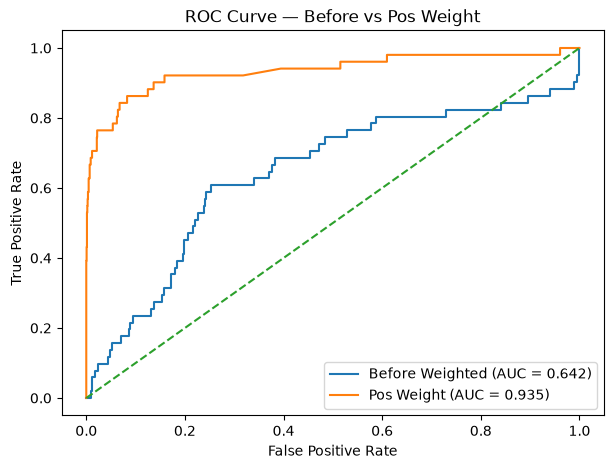

In [30]:
# Get probability predictions
model.eval()
model_weighted.eval()

with torch.no_grad():
    prob = torch.sigmoid(model(X_val_tensor)).numpy().ravel()
    weighted_prob = torch.sigmoid(model_weighted(X_val_tensor)).numpy().ravel()

# ROC curves
fpr_sgd, tpr_sgd, _ = roc_curve(y_val_np, prob)
fpr_weighted, tpr_weighted, _ = roc_curve(y_val_np, weighted_prob)

# ROC-AUC
auc_sgd = roc_auc_score(y_val_np, prob)
auc_weighted = roc_auc_score(y_val_np, weighted_prob)

# Visualization
plt.figure(figsize=(7, 5))

plt.plot(fpr_sgd, tpr_sgd, label=f"Before Weighted (AUC = {auc_sgd:.3f})")
plt.plot(fpr_weighted, tpr_weighted, label=f"Pos Weight (AUC = {auc_weighted:.3f})")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Before vs Pos Weight")
plt.legend()
plt.show()

ROC Curve analysis demonstrating the impact of handling class imbalance in the MLP model. Implementing pos_weight successfully resolves the majority class bias, lifting the AUC score from 0.642 to 0.935.

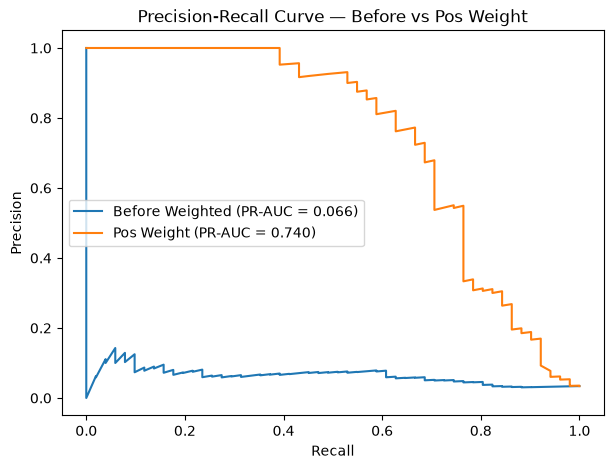

Before Weighted PR-AUC : 0.066
Pos Weight PR-AUC      : 0.740


In [31]:
# Precision-Recall curves
precision, recall, _ = precision_recall_curve(
    y_val_np, prob
)

precision_weighted, recall_weighted, _ = precision_recall_curve(
    y_val_np, weighted_prob
)

# PR-AUC
pr_auc_sgd = average_precision_score(y_val_np, prob)
pr_auc_weighted = average_precision_score(y_val_np, weighted_prob)

# Visualization
plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision,
    label=f"Before Weighted (PR-AUC = {pr_auc_sgd:.3f})"
)

plt.plot(
    recall_weighted,
    precision_weighted,
    label=f"Pos Weight (PR-AUC = {pr_auc_weighted:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Before vs Pos Weight")
plt.legend()
plt.show()

print(f"Before Weighted PR-AUC : {pr_auc_sgd:.3f}")
print(f"Pos Weight PR-AUC      : {pr_auc_weighted:.3f}")


Precision-Recall analysis highlighting the mitigation of majority class bias. Introducing pos_weight successfully enhances the model's ability to detect actual failures, significantly elevating the PR-AUC score from 0.066 to 0.740.

# 8. Hyperparameter Tuning

In [33]:
def train_model(lr, hidden1, hidden2, dropout):
    model = nn.Sequential(
        nn.Linear(X_train_tensor.shape[1], hidden1),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden1, hidden2),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden2, 1)
    )

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9
    )

    for epoch in range(100):
        model.train()

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()

            output = model(X_batch)
            loss = criterion(output, y_batch)

            loss.backward()
            optimizer.step()

    # Validation probability
    model.eval()

    with torch.no_grad():
        prob = torch.sigmoid(model(X_val_tensor)).numpy().ravel()

    pr_auc = average_precision_score(y_val_np, prob)
    roc_auc = roc_auc_score(y_val_np, prob)

    return model, pr_auc, roc_auc

In [34]:
results = []

learning_rates = [0.001, 0.005, 0.01]
hidden_layers = [(64, 32), (128, 64)]
dropouts = [0.2, 0.3]

for lr in learning_rates:
    for hidden1, hidden2 in hidden_layers:
        for dropout in dropouts:

            model, pr_auc, roc_auc = train_model(
                lr,
                hidden1,
                hidden2,
                dropout
            )

            results.append({
                "lr": lr,
                "hidden1": hidden1,
                "hidden2": hidden2,
                "dropout": dropout,
                "PR-AUC": pr_auc,
                "ROC-AUC": roc_auc
            })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "PR-AUC",
    ascending=False
)

,lr,hidden1,hidden2,dropout,PR-AUC,ROC-AUC
11,0.010,128,64,0.3,0.744573,0.933577
0,0.001,64,32,0.2,0.727577,0.937525
3,0.001,128,64,0.3,0.727139,0.940216
6,0.005,128,64,0.2,0.721765,0.934577
10,0.010,128,64,0.2,0.718686,0.926356
2,0.001,128,64,0.2,0.714318,0.935118
7,0.005,128,64,0.3,0.712532,0.935470
5,0.005,64,32,0.3,0.704043,0.938310
4,0.005,64,32,0.2,0.692631,0.940135
1,0.001,64,32,0.3,0.685176,0.941433


**Tuning Result:** The best configuration achieved the highest PR-AUC of 0.745 with a learning rate of 0.01, hidden layers of 128–64, and dropout of 0.3.

**Metric Selection:** PR-AUC was used as the primary metric because the dataset is highly imbalanced. It better reflects the model's ability to detect the minority Failure class than accuracy or ROC-AUC alone.

# Best Model

In [35]:
best_model = nn.Sequential(
    nn.Linear(X_train_tensor.shape[1], 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 1)
)

criterion_best = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer_best = torch.optim.SGD(
    best_model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [36]:
epochs = 100

for epoch in range(epochs):
    best_model.train()

    for X_batch, y_batch in train_loader:
        optimizer_best.zero_grad()

        output = best_model(X_batch)
        loss = criterion_best(output, y_batch)

        loss.backward()
        optimizer_best.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/100], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 0.6881
Epoch [20/100], Loss: 0.3354
Epoch [30/100], Loss: 0.1387
Epoch [40/100], Loss: 0.7468
Epoch [50/100], Loss: 0.1986
Epoch [60/100], Loss: 0.0971
Epoch [70/100], Loss: 0.0341
Epoch [80/100], Loss: 0.8210
Epoch [90/100], Loss: 0.2998
Epoch [100/100], Loss: 0.5679


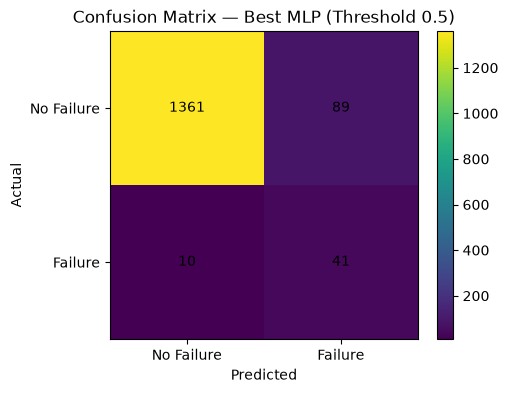

In [37]:
best_model.eval()

with torch.no_grad():
    best_prob = torch.sigmoid(
        best_model(X_val_tensor)
    ).numpy().ravel()

best_pred_05 = (best_prob >= 0.5).astype(int)

cm = confusion_matrix(y_val_np, best_pred_05)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.colorbar()

plt.xticks([0, 1], ["No Failure", "Failure"])
plt.yticks([0, 1], ["No Failure", "Failure"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Best MLP (Threshold 0.5)")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [38]:
# Print classification report
print("Classification Report:\n", classification_report(y_val_np, best_pred_05, target_names=['Loss', 'Win']))

Classification Report:
               precision    recall  f1-score   support

        Loss       0.99      0.94      0.96      1450
         Win       0.32      0.80      0.45        51

    accuracy                           0.93      1501
   macro avg       0.65      0.87      0.71      1501
weighted avg       0.97      0.93      0.95      1501



## Threshold tuning

In [39]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []

for threshold in thresholds:
    pred = (best_prob >= threshold).astype(int)

    precision = precision_score(y_val_np, pred, zero_division=0)
    recall = recall_score(y_val_np, pred, zero_division=0)
    f1 = f1_score(y_val_np, pred, zero_division=0)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Precision,Recall,F1
0,0.30,0.248555,0.843137,0.383929
1,0.35,0.256098,0.823529,0.390698
2,0.40,0.269737,0.803922,0.403941
3,0.45,0.282759,0.803922,0.418367
4,0.50,0.315385,0.803922,0.453039
5,0.55,0.359649,0.803922,0.496970
6,0.60,0.375000,0.764706,0.503226


In [40]:
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax(),
    "Threshold"
]

print(f"Best Threshold: {best_threshold}")

Best Threshold: 0.6


**Threshold Selection:** The optimal threshold was selected based on the highest F1-score for the Failure class. F1-score balances precision and recall, providing a better trade-off between detecting actual failures and reducing false alarms.

In [41]:
final_pred = (best_prob >= best_threshold).astype(int)

print("Classification Report:")
print(
    classification_report(
        y_val_np,
        final_pred,
        target_names=["No Failure", "Failure"],
        zero_division=0
    )
)

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.96      0.97      1450
     Failure       0.38      0.76      0.50        51

    accuracy                           0.95      1501
   macro avg       0.68      0.86      0.74      1501
weighted avg       0.97      0.95      0.96      1501



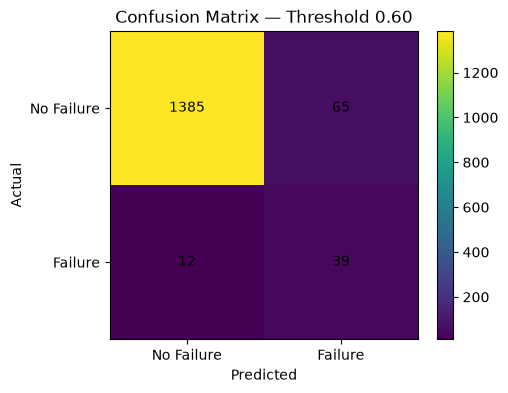

In [42]:
cm = confusion_matrix(y_val_np, final_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.colorbar()

plt.xticks([0, 1], ["No Failure", "Failure"])
plt.yticks([0, 1], ["No Failure", "Failure"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — Threshold {best_threshold:.2f}")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

**Threshold Tuning Result:** After threshold tuning, the Failure F1-score improved from 0.45 to 0.50, while precision increased from 0.32 to 0.38. Although recall slightly decreased from 0.80 to 0.76, the model achieved a better balance between detecting failures and reducing false alarms.

Confusion Matrix comparison between the model evaluated at a 0.60 threshold and the Best MLP model at a 0.50 threshold. 

A classic trade-off between Precision and Recall is observed. Lowering the threshold to 0.50 increases the model's sensitivity, capturing 41 actual failures and reducing missed detections (False Negatives) to just 10. However, this comes at the cost of higher false alarms (89 False Positives). Conversely, raising the threshold to 0.60 significantly mitigates false alarms to 65, leading to a higher overall F1-Score of 50.32%. 

Decision Framework: The final choice depends on operational priorities. The 0.50 threshold is preferred for a "safety-first" strategy where unexpected machine downtime is catastrophic. Meanwhile, the 0.60 threshold is the optimal choice for a cost-efficient strategy aimed at minimizing unnecessary technician dispatches.

In this project we will use and save best model with 0.06 threshold.

# 9. Save Model

In [43]:
import os
import joblib

os.makedirs("../models/mlp", exist_ok=True)

torch.save(
    best_model.state_dict(),
    "../models/mlp/best_mlp.pth"
)

joblib.dump(
    scaler,
    "../models/mlp/scaler.pkl"
)

joblib.dump(
    encoder,
    "../models/mlp/encoder.pkl"
)

joblib.dump(
    best_threshold,
    "../models/mlp/threshold.pkl"
)

print("MLP artifacts saved successfully.")
print(f"Threshold: {best_threshold}")

MLP artifacts saved successfully.
Threshold: 0.6


# 10. Test Set Validation

In [44]:
best_model.eval()

with torch.no_grad():
    test_prob = torch.sigmoid(
        best_model(X_test_tensor)
    ).numpy().ravel()

y_test_np = y_test_tensor.numpy().ravel()

test_pred = (
    test_prob >= best_threshold
).astype(int)

In [45]:
print("Classification Report — Test Set")

print(
    classification_report(
        y_test_np,
        test_pred,
        target_names=["No Failure", "Failure"],
        zero_division=0
    )
)

Classification Report — Test Set
              precision    recall  f1-score   support

  No Failure       1.00      0.95      0.97      1449
     Failure       0.39      0.92      0.55        51

    accuracy                           0.95      1500
   macro avg       0.69      0.94      0.76      1500
weighted avg       0.98      0.95      0.96      1500



In [47]:
test_roc_auc = roc_auc_score(
    y_test_np,
    test_prob
)

test_pr_auc = average_precision_score(
    y_test_np,
    test_prob
)

test_precision = precision_score(
    y_test_np,
    test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test_np,
    test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test_np,
    test_pred,
    zero_division=0
)

print(f"ROC-AUC : {test_roc_auc:.3f}")
print(f"PR-AUC  : {test_pr_auc:.3f}")
print(f"Precision: {test_precision:.3f}")
print(f"Recall   : {test_recall:.3f}")
print(f"F1-score : {test_f1:.3f}")

ROC-AUC : 0.982
PR-AUC  : 0.782
Precision: 0.392
Recall   : 0.922
F1-score : 0.550


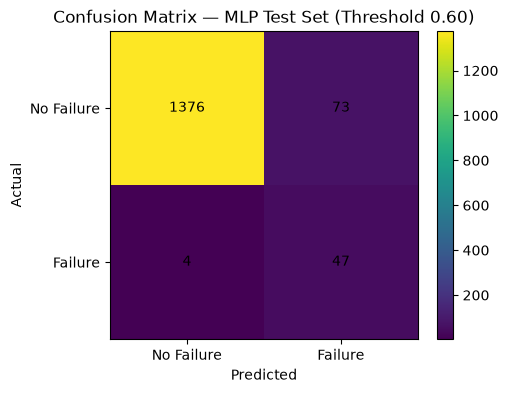

In [46]:
cm_test = confusion_matrix(
    y_test_np,
    test_pred
)

plt.figure(figsize=(5, 4))

plt.imshow(cm_test)
plt.colorbar()

plt.xticks(
    [0, 1],
    ["No Failure", "Failure"]
)

plt.yticks(
    [0, 1],
    ["No Failure", "Failure"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    f"Confusion Matrix — MLP Test Set "
    f"(Threshold {best_threshold:.2f})"
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_test[i, j],
            ha="center",
            va="center"
        )

plt.show()

Conclusion: The MLP model evaluated on the Test Set at a 0.60 threshold demonstrates exceptional performance in predictive maintenance. It successfully captures 47 out of 51 actual failures, achieving a remarkable Recall of 92.15% and a peak F1-Score of 54.97%, making it highly reliable for preventing unexpected machine downtime.

# 11. Feature Important

In [50]:
from sklearn.metrics import average_precision_score

best_model.eval()

# Baseline PR-AUC
with torch.no_grad():
    val_prob = torch.sigmoid(
        best_model(X_val_tensor)
    ).numpy().ravel()

baseline_pr_auc = average_precision_score(
    y_val_np,
    val_prob
)

print(f"Baseline PR-AUC: {baseline_pr_auc:.3f}")

Baseline PR-AUC: 0.703


In [51]:
feature_names_mlp = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Type_H",
    "Type_L",
    "Type_M"
]

rng = np.random.default_rng(42)

importance_results = []

for i, feature_name in enumerate(feature_names_mlp):

    scores = []

    for _ in range(10):

        X_permuted = X_val_processed.copy()

        # Shuffle satu feature
        X_permuted[:, i] = rng.permutation(
            X_permuted[:, i]
        )

        X_permuted_tensor = torch.tensor(
            X_permuted,
            dtype=torch.float32
        )

        with torch.no_grad():
            permuted_prob = torch.sigmoid(
                best_model(X_permuted_tensor)
            ).numpy().ravel()

        permuted_pr_auc = average_precision_score(
            y_val_np,
            permuted_prob
        )

        scores.append(permuted_pr_auc)

    importance = baseline_pr_auc - np.mean(scores)

    importance_results.append({
        "Feature": feature_name,
        "Importance": importance,
        "Std": np.std(scores)
    })

importance_df = pd.DataFrame(
    importance_results
).sort_values(
    "Importance",
    ascending=False
)

importance_df

,Feature,Importance,Std
3,Torque [Nm],0.606465,0.004597
0,Air temperature [K],0.602174,0.008480
2,Rotational speed [rpm],0.565493,0.008791
1,Process temperature [K],0.550773,0.009785
4,Tool wear [min],0.251204,0.030685
7,Type_M,0.169228,0.030446
6,Type_L,0.086193,0.034694
5,Type_H,0.055521,0.020651


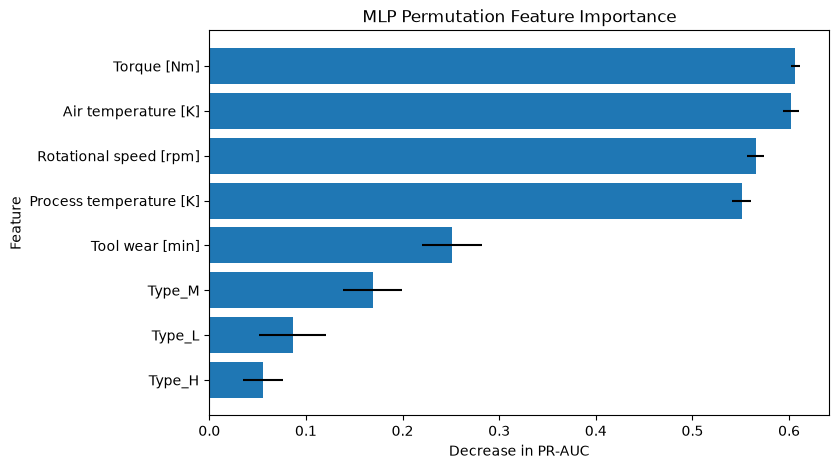

In [52]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"],
    xerr=importance_df["Std"]
)

plt.xlabel("Decrease in PR-AUC")
plt.ylabel("Feature")
plt.title("MLP Permutation Feature Importance")

plt.gca().invert_yaxis()

plt.show()

Interpretation: Permutation importance measures how much PR-AUC decreases when each feature is randomly shuffled. Higher values indicate greater dependence of the MLP on that feature for predictive performance. This measures model reliance, not causal influence.

# 12. SHAP

In [53]:
import shap

d:\proyek\predictive-maintenance-ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [54]:
background = X_train_tensor[:100]

In [55]:
X_explain = X_val_tensor[:10]

In [56]:
best_model.eval()

explainer_mlp = shap.DeepExplainer(
    best_model,
    background
)

In [57]:
shap_values = explainer_mlp.shap_values(
    X_explain
)

In [58]:
print(shap_values.shape)

(10, 8, 1)


In [59]:
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]

print(shap_values.shape)

(10, 8)


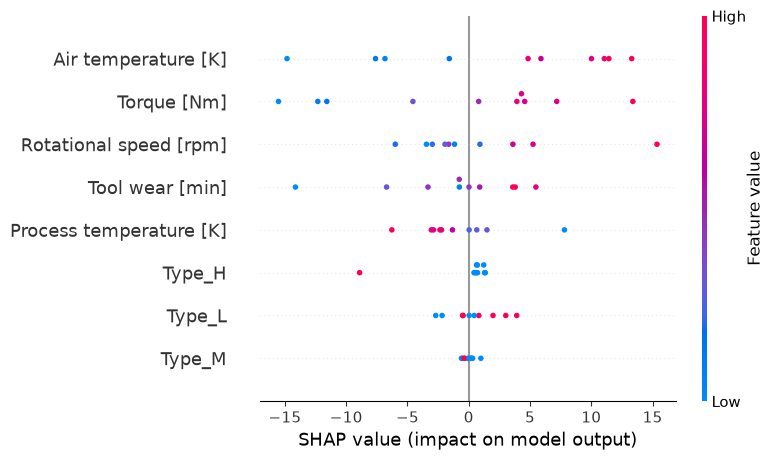

In [60]:
shap.summary_plot(
    shap_values,
    X_explain.numpy(),
    feature_names=feature_names_mlp
)

SHAP summary plot illustrating feature importance and their impact on the MLP model's predictions. Air temperature [K] and Torque [Nm] emerge as the most critical drivers, where high values (represented in red) strongly push the model toward predicting a machine failure (positive SHAP values). Conversely, categorical features like machine types (Type_H, Type_L, Type_M) exert minimal to no global influence on the final model output.

In [61]:
shap_importance = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": feature_names_mlp,
    "Mean |SHAP|": shap_importance
}).sort_values(
    "Mean |SHAP|",
    ascending=False
)

shap_importance_df

,Feature,Mean |SHAP|
0,Air temperature [K],8.740109
3,Torque [Nm],7.814820
2,Rotational speed [rpm],4.228452
4,Tool wear [min],3.948590
1,Process temperature [K],2.809690
5,Type_H,1.640926
6,Type_L,1.605003
7,Type_M,0.364479


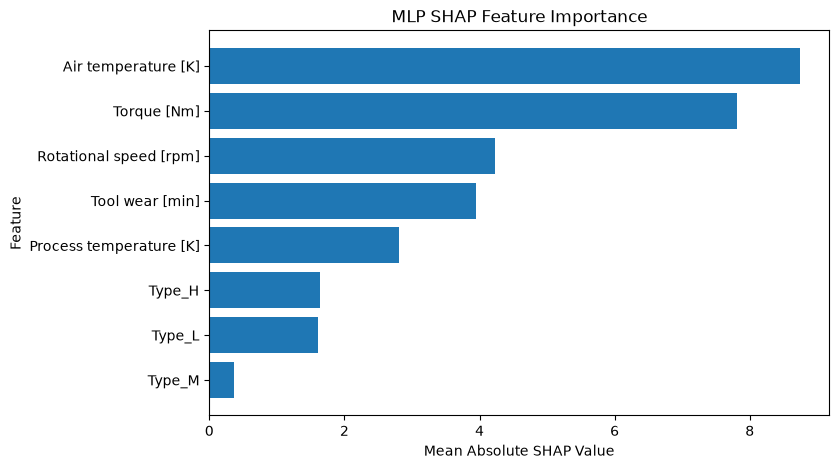

In [62]:
plt.figure(figsize=(8, 5))

plt.barh(
    shap_importance_df["Feature"],
    shap_importance_df["Mean |SHAP|"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("MLP SHAP Feature Importance")

plt.gca().invert_yaxis()

plt.show()

## SHAP Feature Importance

SHAP (SHapley Additive exPlanations) is used to measure how strongly each feature contributes to the MLP predictions. The mean absolute SHAP value represents the average magnitude of a feature's contribution across the explained samples.

Higher values indicate that the model relies more strongly on that feature when generating predictions. This represents model behavior and should not be interpreted as causal influence.

### SHAP Interpretation

The global SHAP analysis shows that Air temperature and Torque have the largest average contributions to the MLP predictions, followed by Rotational speed. Tool wear and Process temperature provide moderate contributions, while the one-hot encoded machine type features have relatively smaller contributions.

The ranking differs slightly from permutation importance because the two methods measure different aspects of model behavior. However, both methods consistently identify Air temperature, Torque, and Rotational speed as important features for the MLP.

## SHAP Waterfall for one failure case

In [63]:
failure_indices = np.where(
    (y_val_np == 1) &
    (val_prob >= best_threshold)
)[0]

print("Number of correctly detected failures:", len(failure_indices))

Number of correctly detected failures: 39


In [64]:
idx = failure_indices[0]

X_single = X_val_tensor[idx:idx+1]

with torch.no_grad():
    single_prob = torch.sigmoid(
        best_model(X_single)
    ).item()

print(f"Failure probability: {single_prob:.3f}")
print(f"Threshold: {best_threshold:.2f}")

Failure probability: 0.918
Threshold: 0.60


In [65]:
shap_single = explainer_mlp.shap_values(
    X_single
)

if isinstance(shap_single, list):
    shap_single = shap_single[0]

shap_single = np.array(shap_single)

if shap_single.ndim == 3:
    shap_single = shap_single[:, :, 0]

print(shap_single.shape)

(1, 8)


In [68]:
shap_explanation = shap.Explanation(
    values=shap_single[0],
    base_values=np.array(explainer_mlp.expected_value).flatten()[0],
    data=X_single.numpy()[0],
    feature_names=feature_names_mlp
)

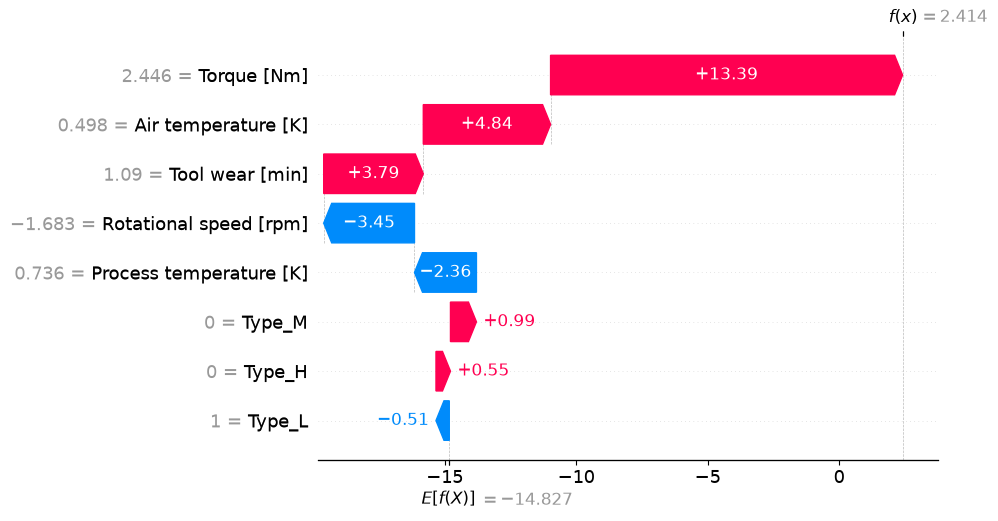

In [69]:
shap.plots.waterfall(
    shap_explanation,
    max_display=8
)

SHAP waterfall plot explaining a single prediction instance where the final model output is \(f(x) = 2.414\), starting from a base value of \(E[f(X)] = -14.827\). The critical driving force pushing the prediction towards a failure classification is Torque [Nm] = 2.446, contributing a massive positive impact of \[+13.39\]. Other significant contributors include Air temperature (\[+4.84\]) and Tool wear (\[+3.79\]), while a negative Rotational speed serves as the primary countervailing factor reducing the risk by \[-3.45\]. 